In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}"
    })

plt.rcParams.update({'font.size': 18, 'axes.titlesize': 22, 'axes.labelsize': 18, 'legend.fontsize': 18, 'xtick.labelsize': 18, 'ytick.labelsize': 18})

seasons = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }



In [4]:
# Update: Use 'lon' and 'lat' as coordinate names and global range
regions_plot = {
    "Africa": {"color": "#c2896c", "lon": [15, 35], "lat": [-20, 5]},
    "Tropical Indian": {"color": "#8fa9b5", "lon": [55, 95], "lat": [-20, 0]},
    "Maritime Continent": {"color": "#bd5172", "lon": [95, 150], "lat": [-10, 10]},
    "North Pacific": {"color": "#797bd0", "lon": [140, 200], "lat": [15, 30]},
    "Tropical Pacific": {"color": "#77587e", "lon": [160, 200], "lat": [-20, 0]},
    "South America": {"color": "#c86c62", "lon": [285, 320], "lat": [-15, 0]},
}

def seasonal_diurnal(ds, region, months):
    ds = ds.assign_coords(lon=(((ds.lon + 360) % 360)))

    seasons_ds = ds.sel(month=months).mean(dim='month')

    seasons_ds_region = seasons_ds.sel(lat=slice(region['lat'][0], region['lat'][1]),
                                       lon=slice(region['lon'][0], region['lon'][1]))

    # Conversion to LST
    utc_hour = ds['hour_of_day']
    # For 30-min
    
    lst = (utc_hour + ds['lon'] / 360 * 24) % 24
    seasons_ds_region_lst = seasons_ds_region.assign_coords(LST=lst)

    seasons_ds_region_lst_stack = (
        seasons_ds_region_lst
        .stack(points=('hour_of_day', 'lon'))
        .groupby_bins('LST', np.arange(0, 25, 1)) #.groupby_bins('LST', np.arange(0, 24.5, 0.5)) 
        .mean('points')
)

    # Weighted average
    weights = np.cos(np.deg2rad(seasons_ds_region_lst['lat']))
    # no weights
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    seasons_ds_region_lst_avg = seasons_ds_region_lst_stack.weighted(weights).mean(dim=["lat"])

    return seasons_ds_region_lst_avg


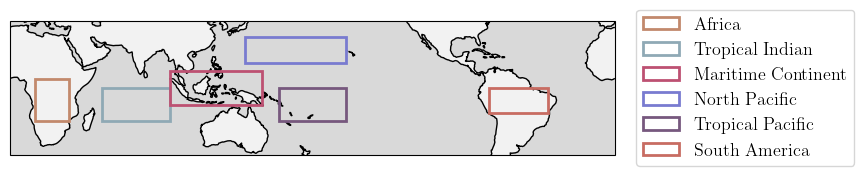

In [3]:
plt.figure(figsize=(9, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([0,360, -40, 40],crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='0.95')
ax.add_feature(cfeature.OCEAN, facecolor='0.85')

handles = []
labels = []
# Draw region boxes
for region, props in regions_plot.items():
    lon0, lon1 = props['lon']
    lat0, lat1 = props['lat']
    width = lon1 - lon0
    height = lat1 - lat0
    rect = Rectangle((lon0, lat0), 
                     width, height, 
                     transform=ccrs.PlateCarree(),
                     linewidth=2, edgecolor=props['color'], 
                     facecolor='none', zorder=5, label=region)
    ax.add_patch(rect)
    handles.append(rect)
    labels.append(region)
    # Place label at top left of box

#plt.title('Regions Used for Diurnal Cycle Analysis', fontsize=18)
# Place legend outside the plot
ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=13, frameon=True)
plt.tight_layout()
plt.savefig('../pdf/Region_definition.pdf')
plt.show()

## FWP - CCIC and ERA5

<>:64: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:64: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/tmp/ipykernel_3353310/1836057249.py:64: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax.set_ylabel('FWP kg/m²' if not RELATIVE else 'Relative Deviation (\%)')


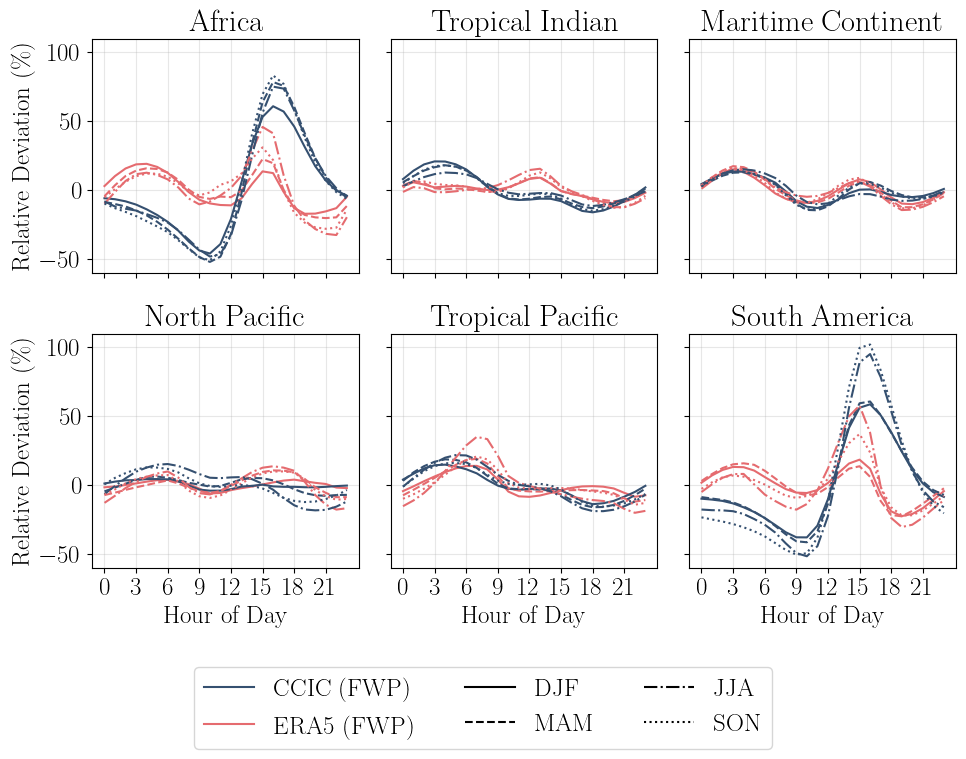

In [ ]:
CCIC_TIWP = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2023_utc.nc').tiwp
ERA5 = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ERA5/ERA5_diurnal_climatology_2018_2023_utc.nc').tiwp
# Define seasons as month lists
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

# Variable names (update if needed)
er_var = 'tiwp'  # or the correct variable name in ERA5
ccic_var = 'tiwp'  # or the correct variable name in CCIC

season_linestyles = [
    '-',
    '--',
    '-.',
    ':'
]

season_names = [
    'DJF',
    'MAM',
    'JJA',
    'SON'
]

ccic_color = '#355070'  
era5_color = '#e56b6fff' 
ratio = [2,3]
figsize = (10, 7)

#ratio = [6,1]
#figsize = (8, 22)

RELATIVE = True

fig, axes = plt.subplots(ratio[0], ratio[1], figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax = axes[i]
    for j, (season, months) in enumerate(seasons.items()):
        # ERA5
        era5_cycle = seasonal_diurnal(ERA5, region, months)
        if RELATIVE:
            era5_cycle = (era5_cycle / era5_cycle.mean() -1)*100
        ax.plot(ERA5['hour_of_day'], era5_cycle, label=f'ERA5 {season}', color=era5_color, linestyle=season_linestyles[j])
        # CCIC
        ccic_cycle = seasonal_diurnal(CCIC_TIWP, region, months)
        if RELATIVE:
            ccic_cycle = (ccic_cycle / ccic_cycle.mean() -1)*100
        ax.plot(CCIC_TIWP['hour_of_day'], ccic_cycle, label=f'CCIC {season}', color=ccic_color, linestyle=season_linestyles[j])
    ax.set_title(region_name)
    ax.set_xticks([0,3,6,9,12,15,18,21])
    ax.grid(True, alpha=0.3)
    if i >= (ratio[0]-1)*ratio[1]:
        ax.set_xlabel('Hour of Day')
    if i % ratio[1] == 0:
        ax.set_ylabel('FWP kg/m²' if not RELATIVE else 'Relative Deviation (\%)')
        

import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color = ccic_color, label='CCIC (FWP)'),
    mlines.Line2D([], [], color = era5_color, label='ERA5 (FWP)')
]
season_handles = [
    mlines.Line2D([], [], color='black', linestyle=season_linestyles[i], label=season_names[i])
    for i in range(4)
 ]

fig.legend(dataset_handles + season_handles, [h.get_label() for h in dataset_handles + season_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, frameon=True)

#plt.suptitle('Seasonal Diurnal Cycles: ERA5 vs CCIC', fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../pdf/Regional_diurnal_ERA5_CCIC' + ('_relative' if RELATIVE else '') + '.pdf', bbox_inches='tight')
plt.show()


## Precipitation - IMERG and ERA5

<>:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/tmp/ipykernel_1257740/2561702068.py:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax.set_ylabel('Precipitation (mm/hr)' if not RELATIVE else 'Relative Precipitation Deviation (\%)')


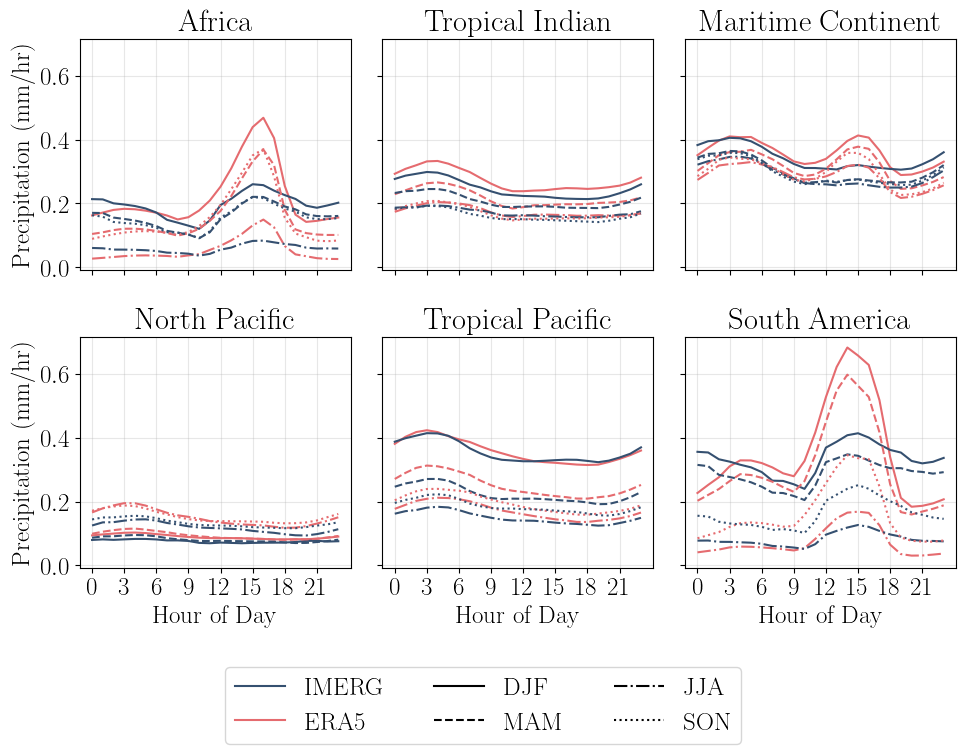

In [5]:
IMERG = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023_utc.nc').pr
ERA5 = xr.open_dataset('/scratch/leko/ERA5/ERA5_1_deg_diurnal/ERA5_diurnal_climatology_2018_2023_utc.nc').pr

# Define seasons as month lists
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

# Variable names (update if needed)
er_var = 'pr'  # or the correct variable name in ERA5
imerg_var = 'pr'  # or the correct variable name in IMERG

# Colors and linestyles for datasets and seasons
imerg_color = '#355070' 
era5_color = '#e56b6fff'

season_linestyles = ['-', '--', '-.', ':']
season_names = ['DJF', 'MAM', 'JJA', 'SON']

ratio = [2,3]
figsize = (10, 7)

RELATIVE = False

fig, axes = plt.subplots(ratio[0], ratio[1], figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax = axes[i]
    for j, (season, months) in enumerate(seasons.items()):
        # ERA5
        era5_cycle = seasonal_diurnal(ERA5, region, months)
        if RELATIVE:
            era5_cycle = (era5_cycle / era5_cycle.mean() - 1) * 100
        ax.plot(ERA5['hour_of_day'], era5_cycle, label=f'ERA5 {season}', color=era5_color, linestyle=season_linestyles[j])
        # IMERG
        imerg_cycle = seasonal_diurnal(IMERG, region, months)
        if RELATIVE:
            imerg_cycle = (imerg_cycle / imerg_cycle.mean() - 1) * 100
        ax.plot(IMERG['hour_of_day'], imerg_cycle, label=f'IMERG {season}', color=imerg_color, linestyle=season_linestyles[j])
    ax.set_title(region_name)
    ax.set_xticks([0,3,6,9,12,15,18,21])
    ax.grid(True, alpha=0.3)
    if i >= (ratio[0]-1)*ratio[1]:
        ax.set_xlabel('Hour of Day')
    if i % ratio[1] == 0:
        ax.set_ylabel('Precipitation (mm/hr)' if not RELATIVE else 'Relative Precipitation Deviation (\%)')

import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color=imerg_color, label='IMERG'),
    mlines.Line2D([], [], color=era5_color, label='ERA5')
]
season_handles = [
    mlines.Line2D([], [], color='black', linestyle=season_linestyles[i], label=season_names[i])
    for i in range(4)
]

fig.legend(dataset_handles + season_handles, [h.get_label() for h in dataset_handles + season_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, frameon=True)

#plt.suptitle('Seasonal Diurnal Cycles: ERA5 vs IMERG', fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../pdf/Regional_diurnal_ERA5_IMERG' + ('_relative' if RELATIVE else '') + '.pdf', bbox_inches='tight')
plt.show()

## HCC - CCIC and ERA5 

<>:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/tmp/ipykernel_1257740/2271734932.py:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax.set_ylabel('High Cloud Cover (\%)' if not RELATIVE else 'Relative High Cloud Cover (\%)')
/tmp/ipykernel_1257740/2271734932.py:50: SyntaxWarning: "\%" is an invalid escape sequence. Such sequ

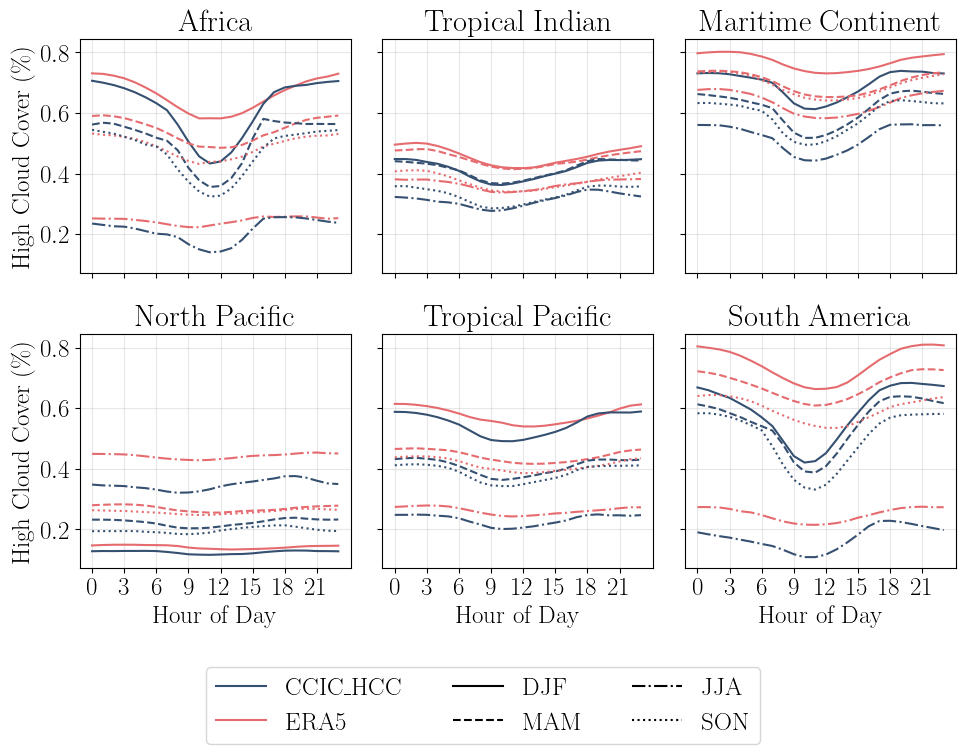

In [6]:
CCIC_HCC = xr.open_dataset('/scratch/leko/HCC/HCC_diurnal_climatology_2018_2023_utc.nc').hcc
#CCIC_HCC = CCIC_HCC.squeeze('threshold')
ERA5 = xr.open_dataset('/scratch/leko/HCC/ERA5/ERA5_1_deg_diurnal/2018/ERA5_hcc_diurnal_climatology_2018_utc.nc').hcc

# Define seasons as month lists
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

# Variable names (update if needed)
er_var = 'hcc'  # or the correct variable name in ERA5
imerg_var = 'hcc'  # or the correct variable name in IMERG

# Colors and linestyles for datasets and seasons
ccic_color = '#355070' 
era5_color = '#e56b6fff'
season_linestyles = ['-', '--', '-.', ':']
season_names = ['DJF', 'MAM', 'JJA', 'SON']

ratio = [2,3]
figsize = (10, 7)

RELATIVE = False

fig, axes = plt.subplots(ratio[0], ratio[1], figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax = axes[i]
    for j, (season, months) in enumerate(seasons.items()):
        # ERA5
        era5_cycle = seasonal_diurnal(ERA5, region, months)
        if RELATIVE:
            era5_cycle = (era5_cycle / era5_cycle.mean() - 1) * 100
        ax.plot(ERA5['hour_of_day'], era5_cycle, label=f'ERA5 {season}', color=era5_color, linestyle=season_linestyles[j])
        # IMERG
        ccic_cycle = seasonal_diurnal(CCIC_HCC, region, months)
        if RELATIVE:
            ccic_cycle = (ccic_cycle / ccic_cycle.mean() - 1) * 100
        ax.plot(CCIC_HCC['hour_of_day'], ccic_cycle, label=f'CCIC_HCC {season}', color=ccic_color, linestyle=season_linestyles[j])
    ax.set_title(region_name)
    ax.set_xticks([0,3,6,9,12,15,18,21])
    ax.grid(True, alpha=0.3)
    if i >= (ratio[0]-1)*ratio[1]:
        ax.set_xlabel('Hour of Day')
    if i % ratio[1] == 0:
        ax.set_ylabel('High Cloud Cover (\%)' if not RELATIVE else 'Relative High Cloud Cover (\%)')

import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color=ccic_color, label='CCIC_HCC'),
    mlines.Line2D([], [], color=era5_color, label='ERA5')
]
season_handles = [
    mlines.Line2D([], [], color='black', linestyle=season_linestyles[i], label=season_names[i])
    for i in range(4)
]

fig.legend(dataset_handles + season_handles, [h.get_label() for h in dataset_handles + season_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, frameon=True)

#plt.suptitle('Seasonal Diurnal Cycles: ERA5 vs CCIC_HCC', fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../pdf/Regional_diurnal_ERA5_CCIC_HCC' + ('_relative' if RELATIVE else '') + '.pdf', bbox_inches='tight')
plt.show()

## CCIC IMERG

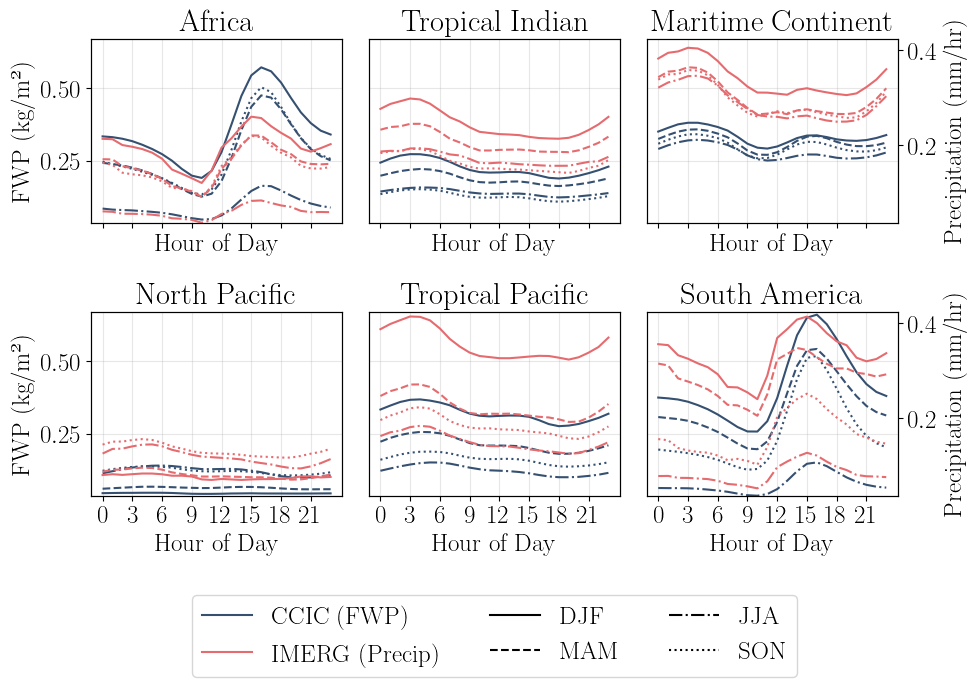

Saved figure to ../pdf/Regional_diurnal_CCIC_IMERG.pdf


In [7]:
# Plot CCIC TIWP diurnal climatology and IMERG diurnal climatology for comparison

IMERG = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023_utc.nc').pr
CCIC_TIWP = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_2023_utc.nc').tiwp
# Option to show relative values (divide by mean)
show_relative = False  # Set to True for relative values
same_y_axis = True  # Set to True to have same y-axis for all subplots
# Define seasons as month lists
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

# Variable names (update if needed)
ccic_var = 'tiwp'  # or the correct variable name in ccic
imerg_var = 'pr'  # or the correct variable name in IMERG

# Colorblind-friendly palette (matplotlib tab10)
season_linestyles = [
    '-',
    '--',
    '-.',
    ':'
]

ccic_color = '#355070'  
imerg_color = '#e56b6fff' 
season_names = ['DJF', 'MAM', 'JJA', 'SON']
ratio = [2,3]
figsize = (10, 6)

fig, axes = plt.subplots(ratio[0], ratio[1], figsize=figsize, sharex=True, sharey=False)
axes = axes.flatten()

# Have the same y axis for all subplots
ccic_min, ccic_max = np.inf, -np.inf
imerg_min, imerg_max = np.inf, -np.inf
for region in regions_plot.values():
    for months in seasons.values():
        ccic_cycle = seasonal_diurnal(CCIC_TIWP, region, months)
        imerg_cycle = seasonal_diurnal(IMERG, region, months)
        if show_relative:
            ccic_cycle = (ccic_cycle / ccic_cycle.mean() -1)*100
            imerg_cycle = (imerg_cycle / imerg_cycle.mean() -1)*100
        ccic_min = min(ccic_min, float(np.nanmin(ccic_cycle)))
        ccic_max = max(ccic_max, float(np.nanmax(ccic_cycle)))
        imerg_min = min(imerg_min, float(np.nanmin(imerg_cycle)))
        imerg_max = max(imerg_max, float(np.nanmax(imerg_cycle)))
                                                   

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    for j, (season, months) in enumerate(seasons.items()):
        # CCIC (TIWP) on left y-axis
        ccic_cycle = seasonal_diurnal(CCIC_TIWP, region, months)
        if show_relative:
            ccic_cycle = (ccic_cycle / ccic_cycle.mean() -1)*100
        ax1.plot(np.arange(0,24,1), ccic_cycle, color=ccic_color, linestyle=season_linestyles[j])
        # IMERG (Precipitation) on right y-axis
        imerg_cycle = seasonal_diurnal(IMERG, region, months)
        if show_relative:
            imerg_cycle = (imerg_cycle / imerg_cycle.mean() -1)*100
        ax2.plot(np.arange(0,24,1), imerg_cycle, color=imerg_color, linestyle=season_linestyles[j])
    ax1.set_title(region_name)
    ax1.set_xlabel('Hour of Day')
    ax1.set_xticks([0,3,6,9,12,15,18,21])
    # Only set y-labels on leftmost and rightmost subplots
    is_leftmost = (i % ratio[1] == 0)
    is_rightmost = ((i + 1) % ratio[1] == 0)
    if is_leftmost:
        ax1.set_ylabel('FWP (kg/m²)' if not show_relative else 'Relative FWP', color='black')
    else:
        ax1.set_ylabel('')
    if is_rightmost:
        ax2.set_ylabel('Precipitation (mm/hr)' if not show_relative else 'Relative Precipitation', color='black')
    else:
        ax2.set_ylabel('')
    # Manage tick visibility: show left y-ticks only for leftmost column, right y-ticks only for rightmost column
    ax1.tick_params(axis='y', which='both', labelleft=is_leftmost, left=is_leftmost)
    ax2.tick_params(axis='y', which='both', labelright=is_rightmost, right=is_rightmost)
    ax1.grid(True, alpha=0.3)
    if same_y_axis:
        ax1.set_ylim(ccic_min, ccic_max + 0.01)
        ax2.set_ylim(imerg_min, imerg_max + 0.01)

# Custom legend handles
import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color=ccic_color, label='CCIC (FWP)'),
    mlines.Line2D([], [], color=imerg_color, label='IMERG (Precip)')
]
season_handles = [
    mlines.Line2D([], [], color='black', linestyle=season_linestyles[i], label=season_names[i])
    for i in range(4)
 ]

fig.legend(dataset_handles + season_handles, [h.get_label() for h in dataset_handles + season_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, frameon=True)

#plt.suptitle('Seasonal Diurnal Cycles: CCIC CPCIR (FWP) vs IMERG (Precip)' + (' (Relative)' if show_relative else ''), fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 1])
name = '../pdf/Regional_diurnal_CCIC_IMERG' + ('_relative' if show_relative else '') + ('_dify' if not same_y_axis else '') + '.pdf'
plt.savefig(name, bbox_inches='tight')
plt.show()
print(f'Saved figure to {name}')

## CCIC HCC, TIWP and IMERG

<>:109: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:109: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/tmp/ipykernel_3353310/3035840109.py:109: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax3.set_ylabel('High Cloud Cover (\%)' if not show_relative else 'Relative High Cloud Cover', color='grey', labelpad=64)


Saving ../pdf/Regional_diurnal_CCIC_HCC_IMERG_SON.pdf


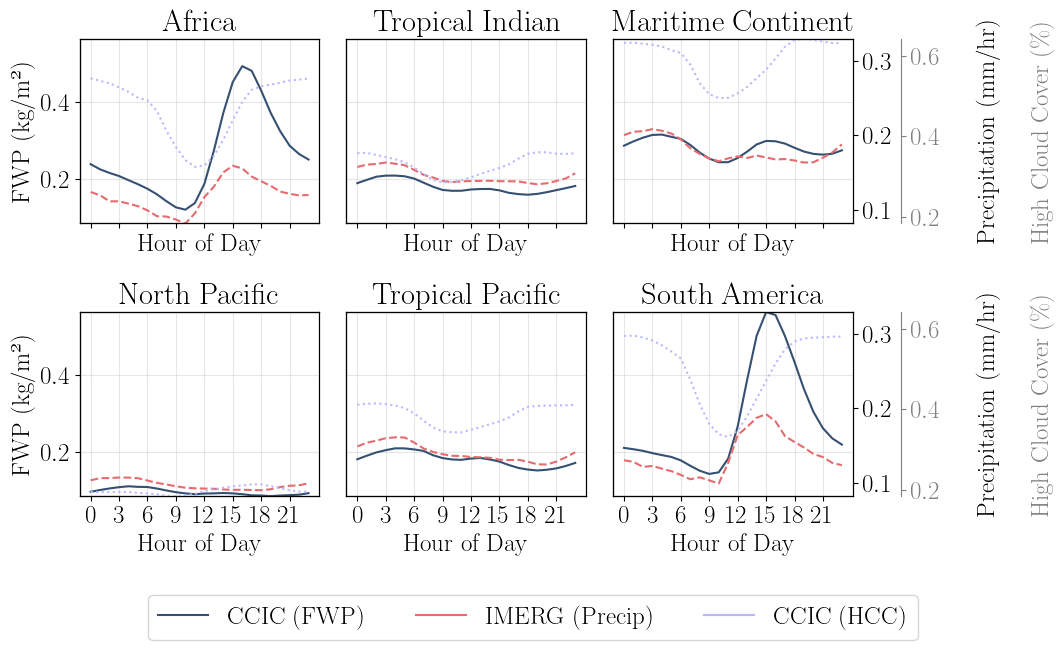

In [10]:
# Summer rain, ice and cloud cover
IMERG = xr.open_dataset("/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_utc.nc").pr
CCIC_TIWP = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018_utc.nc').tiwp
HCC = xr.open_dataset('/scratch/leko/HCC/HCC_diurnal_climatology_2018_utc.nc').hcc

# Option to show relative values (divide by mean)
show_relative = False  # Set to True for relative values

# Define seasons as month lists
seasons = {
    #"DJF": [12, 1, 2],
    #"MAM": [3, 4, 5],
    #"JJA": [6, 7, 8],
    "SON": [9, 10, 11]
}

# Variable names (update if needed)
ccic_var = 'tiwp'  # or the correct variable name in ccic
imerg_var = 'pr'  # or the correct variable name in IMERG
hcc_var = 'hcc'

# Colorblind-friendly palette (matplotlib tab10)
ds_linestyles = [
    '-',
    '--',
    ':'
]

# ccic_color = '#355070'  
# imerg_color = '#e56b6fff' 
# hcc_color = '#eaac8bff'

ccic_color = '#355070'  
imerg_color = '#e56b6fff' 
hcc_color = '#B8B8FF'
season_names = [#'DJF',
                #'MAM',
                #'JJA',
                'SON'
                ]
ratio = [2,3]
figsize = (11, 6)

share_y_axes = True

if share_y_axes:
    ccic_min, ccic_max = np.inf, -np.inf
    imerg_min, imerg_max = np.inf, -np.inf
    hcc_min, hcc_max = np.inf, -np.inf
    for region in regions_plot.values():
        for months in seasons.values():
            ccic_cycle = seasonal_diurnal(CCIC_TIWP, region, months)
            imerg_cycle = seasonal_diurnal(IMERG, region, months)
            hcc_cycle = seasonal_diurnal(HCC, region, months)
            if show_relative:
                ccic_cycle = (ccic_cycle / ccic_cycle.mean() -1)
                imerg_cycle = (imerg_cycle / imerg_cycle.mean() -1)
                hcc_cycle = (hcc_cycle / hcc_cycle.mean() -1)
            ccic_min = min(ccic_min, float(np.nanmin(ccic_cycle)))
            ccic_max = max(ccic_max, float(np.nanmax(ccic_cycle)))
            imerg_min = min(imerg_min, float(np.nanmin(imerg_cycle)))
            imerg_max = max(imerg_max, float(np.nanmax(imerg_cycle)))
            hcc_min = min(hcc_min, float(np.nanmin(hcc_cycle)))
            hcc_max = max(hcc_max, float(np.nanmax(hcc_cycle)))


fig, axes = plt.subplots(ratio[0], ratio[1], figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax1 = axes[i]
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    # Offset the third axis to the right
    ax3.spines["right"].set_position(("axes", 1.20))
    ax3.spines["right"].set_visible(True)
    ax3.spines["right"].set_color("gray")
    ax3.yaxis.label.set_color("gray")
    ax3.tick_params(axis='y', colors='gray')

    for j, (season, months) in enumerate(seasons.items()):
        # CCIC (TIWP) on left y-axis
        ccic_cycle = seasonal_diurnal(CCIC_TIWP, region, months)
        if show_relative:
            ccic_cycle = (ccic_cycle / ccic_cycle.mean() -1)
        ax1.plot(CCIC_TIWP['hour_of_day'], ccic_cycle, color=ccic_color, linestyle=ds_linestyles[0])
        # IMERG (Precipitation) on right y-axis
        imerg_cycle = seasonal_diurnal(IMERG, region, months)
        if show_relative:
            imerg_cycle = (imerg_cycle / imerg_cycle.mean() -1)
        ax1.plot(IMERG['hour_of_day'], imerg_cycle, color=imerg_color, linestyle=ds_linestyles[1])
        # # CCIC (HCC) on right y-axis
        hcc_cycle = seasonal_diurnal(HCC, region, months)
        if show_relative:
            hcc_cycle = (hcc_cycle / hcc_cycle.mean() -1)
        ax3.plot(HCC['hour_of_day'], hcc_cycle, color=hcc_color, linestyle=ds_linestyles[2])
    ax1.set_title(region_name)
    ax1.set_xlabel('Hour of Day')
    ax1.set_xticks([0,3,6,9,12,15,18,21])
    # Only set y-labels on leftmost and rightmost subplots
    is_leftmost = (i % ratio[1] == 0)
    is_rightmost = ((i + 1) % ratio[1] == 0)
    if is_leftmost:
        ax1.set_ylabel('FWP (kg/m²)' if not show_relative else 'Relative TIWP', color='black')
    else:
        ax1.set_ylabel('')
    if is_rightmost:
        ax2.set_ylabel('Precipitation (mm/hr)' if not show_relative else 'Relative Precipitation', color='black', labelpad=60)
        ax3.set_ylabel('High Cloud Cover (\%)' if not show_relative else 'Relative High Cloud Cover', color='grey', labelpad=64)
    else:
        ax2.set_ylabel('')
    # Manage tick visibility: show left y-ticks only for leftmost column, right y-ticks only for rightmost column
    ax1.tick_params(axis='y', which='both', labelleft=is_leftmost, left=is_leftmost)
    ax2.tick_params(axis='y', which='both', labelright=is_rightmost, right=is_rightmost)
    ax3.tick_params(axis='y', which='both', labelright=is_rightmost, right=is_rightmost)
    # hide third axis spine when not rightmost
    ax3.spines['right'].set_visible(is_rightmost)
    if share_y_axes:
        ax1.set_ylim(ccic_min, ccic_max)
        ax2.set_ylim(imerg_min, imerg_max)
        ax3.set_ylim(hcc_min, hcc_max)
    ax1.grid(True, alpha=0.3)

# Custom legend handles
import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color=ccic_color, label='CCIC (FWP)'),
    mlines.Line2D([], [], color=imerg_color, label='IMERG (Precip)'),
    mlines.Line2D([], [], color=hcc_color, label='CCIC (HCC)')
]

fig.legend(dataset_handles, [h.get_label() for h in dataset_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3, frameon=True)

#plt.suptitle('Seasonal Diurnal Cycles: CCIC CPCIR (TIWP) vs IMERG (Precip)' + (' (Relative)' if show_relative else ''), fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 1])
name = f'../pdf/Regional_diurnal_CCIC_HCC_IMERG_{season_names[0]}' + ('_relative' if show_relative else '') +("_dify" if not share_y_axes else "")+ '.pdf'
plt.savefig(name, bbox_inches='tight')
print(f"Saving {name}")
plt.show()

## DYAMOND, CCIC, ERA

In [9]:
CCIC = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_feb2020_utc.nc')
ERA5 = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ERA5/ERA5_diurnal_feb2020_utc.nc')

MODELS = {
    "ARPEGE": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/ARPEGE_diurnal_feb2020_utc.nc'),
    "GEOS": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GEOS_diurnal_feb2020_utc.nc'),
    "GSAM": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GSAM_diurnal_feb2020_utc.nc'), 
    "ICON": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/ICON_diurnal_feb2020_utc.nc'),
    "IFS": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/IFS_diurnal_feb2020_utc.nc'),
    "MPAS": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/MPAS_diurnal_feb2020_utc.nc'),
    "GEM": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GEM_diurnal_feb2020_utc.nc'),
    'GFDL': xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GFDL_diurnal_feb2020_utc.nc'),
    "GRIST": xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/GRIST_diurnal_feb2020_utc.nc')
}

["ARPEGE", "GEOS", "GSAM", "ICON", "IFS", "MPAS", "GEM", "GFDL", "GRIST"]

regions_plot = {
    "Africa": {"color": "#eaac8bff", "lon": [15, 35], "lat": [-20, 5]},
    "Tropical Indian": {"color": "#b56576ff", "lon": [55, 95], "lat": [-20, 0]},
    "Maritime Continent": {"color": "#e56b6fff", "lon": [95, 150], "lat": [-10, 10]},
    "North Pacific": {"color": "#355070ff", "lon": [140, 200], "lat": [15, 30]},
    "Tropical Pacific": {"color": "#6d597aff", "lon": [160, 200], "lat": [-20, 0]},
    "South America": {"color": "#e88c7dff", "lon": [285, 320], "lat": [-15, 0]},
}

# Function to compute regional mean for a single month (February)
def regional_diurnal_feb(ds, var, region):
    ds = ds[var]
    da = ds.assign_coords(lon=(((ds.lon + 360) % 360)))
    if 'month' in ds:
        feb_ds = da.sel(month=2)
    else:
        feb_ds = da
    feb_ds_region = feb_ds.sel(lat=slice(region['lat'][0], region['lat'][1]),
                               lon=slice(region['lon'][0], region['lon'][1]))
    # Conversion to LST
    utc_hour = ds['hour_of_day']
    lst = (utc_hour + ds['lon'] / 360 * 24) % 24
    feb_ds_region_lst = feb_ds_region.assign_coords(LST=lst)    
    feb_ds_region_lst_stack = (
        feb_ds_region_lst
        .stack(points=('hour_of_day', 'lon'))
        .groupby_bins('LST', np.arange(0, 25, 1))
        .mean('points')
    )
    # Weighted average
    weights = np.cos(np.deg2rad(feb_ds_region_lst['lat']))
    weights.name = "weights"
    # Weighted mean over lat/lon/month
    feb_ds_region_lst_avg = feb_ds_region_lst_stack.weighted(weights).mean(dim=["lat"])
    return feb_ds_region_lst_avg

    



In [9]:
xr.open_dataset('/data/s5/users/lara/master_thesis/data/DYAMOND/ICON/ICON_202002_1deg_tiwp.nc')

<xarray.Dataset> Size: 4MB
Dimensions:    (hour: 24, latitude: 120, longitude: 360)
Coordinates:
  * hour       (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23
  * latitude   (latitude) float64 960B -59.5 -58.5 -57.5 ... 57.5 58.5 59.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    TIWP       (hour, latitude, longitude) float32 4MB ...
Attributes:
    CDI:                       Climate Data Interface version 2.4.4 (https://...
    Conventions:               CF-1.6
    source:                    git@gitlab.dkrz.de:icon/icon-aes.git@432d202fb...
    institution:               Max Planck Institute for Meteorology
    history:                   Wed Jan 15 15:43:57 2025: cdo -setreftime,2020...
    title:                     ICON simulation
    references:                see MPIM/DWD publications
    comment:                   Sapphire Dyamond (k203123) on m21097 (Linux 2....
    cdo_openmp_thread_number:  4
    CDO:                       Climate Data Operators version 2.4.4 (https://...

<>:66: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:66: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/tmp/ipykernel_3353310/3410312020.py:66: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax.set_ylabel('FWP (\%)' if RELATIVE else 'FWP kg/m²')


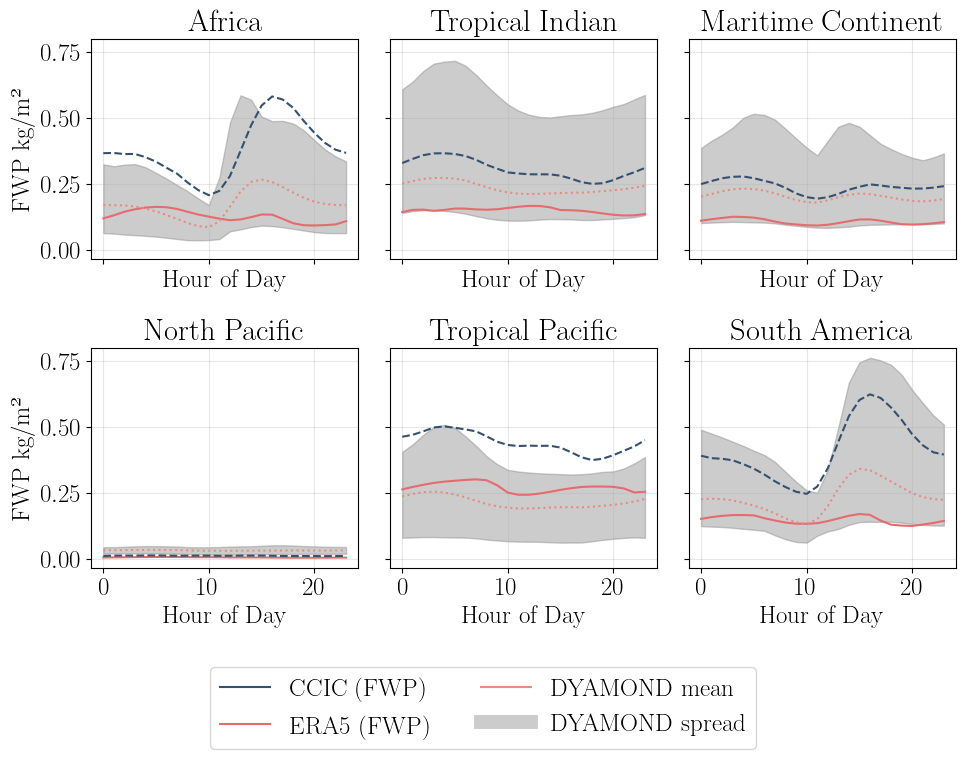

Saved figure to ../pdf/Regional_diurnal_feb2020_ERA5_CCIC_TIWP_DYAMOND.pdf


In [12]:

# Variable names
er_var = 'tiwp'
imerg_var = 'tiwp'
model_var = 'tiwp'

ratio = [2,3]
figsize = (10, 7)

RELATIVE = False
fig, axes = plt.subplots(ratio[0], ratio[1], figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

ccic_color = '#355070'  
era5_color = '#e56b6fff' 
dyamond_color = '#E88C7D'

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax = axes[i]
    # ERA5
    era5_cycle = regional_diurnal_feb(ERA5, er_var, region)
    if RELATIVE:
        era5_cycle = (era5_cycle / era5_cycle.mean() - 1) * 100
    ax.plot(ERA5['hour_of_day'], era5_cycle, label='ERA5', color = era5_color, linestyle='-')
    # CCIC
    imerg_cycle = regional_diurnal_feb(CCIC, imerg_var, region)
    if RELATIVE: 
        imerg_cycle = (imerg_cycle / imerg_cycle.mean() - 1) * 100
    ax.plot(CCIC['hour_of_day'], imerg_cycle, label='CCIC', color = ccic_color, linestyle='--')

    # DYAMOND MODELS
    dyamond_cycles_avg = []
    for name, ds in MODELS.items():
        ds = ds.assign_coords(lon=((ds.lon + 360) % 360)).sortby('lon')
        cycle = regional_diurnal_feb(ds, model_var, region)
        if RELATIVE:
            cycle = (cycle / cycle.mean() - 1) * 100
        dyamond_cycles_avg.append(cycle.values)

    # plot average dyamond cycle
    cycle_avg = np.mean(dyamond_cycles_avg, axis=0)
    ax.plot(ds['hour_of_day'], cycle_avg, label='DYAMOND mean', color = dyamond_color, linestyle=':')
                     
    
    # DYAMOND spread
    dyamond_cycles = []
    for name, ds in MODELS.items():
        try:
            ds = ds.assign_coords(lon=((ds.lon + 360) % 360)).sortby('lon')
            cycle = regional_diurnal_feb(ds, model_var, region)
            if RELATIVE:
                cycle = (cycle / cycle.mean() - 1) * 100
            dyamond_cycles.append(cycle.values)
        except Exception as e:
            print(f"Skipping {name}: {e}")
    if dyamond_cycles:
        dyamond_cycles = np.stack(dyamond_cycles)
        min_cycle = np.min(dyamond_cycles, axis=0)
        max_cycle = np.max(dyamond_cycles, axis=0)
        ax.fill_between(ERA5['hour_of_day'], min_cycle, max_cycle, color='gray', alpha=0.4, label='DYAMOND spread')
    
    ax.set_title(region_name)
    ax.set_xlabel('Hour of Day')
    if i >= (ratio[0]-1)*ratio[1]:
        ax.set_xlabel('Hour of Day')
    if i % ratio[1] == 0:
        ax.set_ylabel('FWP (\%)' if RELATIVE else 'FWP kg/m²')
    ax.grid(True, alpha=0.3)

import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color=ccic_color, label='CCIC (FWP)'),
    mlines.Line2D([], [], color=era5_color, label='ERA5 (FWP)'),
    mlines.Line2D([], [], color=dyamond_color, label='DYAMOND mean'),
    mlines.Line2D([], [], color='gray', alpha=0.4, linewidth=10,label='DYAMOND spread')
]

fig.legend(dataset_handles, [h.get_label() for h in dataset_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2, frameon=True)


plt.tight_layout(rect=[0, 0, 1, 0.96])
name = '../pdf/Regional_diurnal_feb2020_ERA5_CCIC_TIWP_DYAMOND' + ('_relative' if RELATIVE else '') + '.pdf'
plt.savefig(name, bbox_inches='tight')
plt.show()
print(f'Saved figure to {name}')




## DYAMOND, IMERG, ERA5

In [10]:
# February 2020 diurnal cycles for DYAMOND models
IMERG = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_feb2020_utc.nc')
ERA5 = xr.open_dataset('/scratch/leko/ERA5/ERA5_1_deg_diurnal/ERA5_diurnal_feb2020_utc.nc')

IMERG = IMERG.assign_coords(lon=((IMERG.lon + 360) % 360)).sortby('lon')
ERA5 = ERA5.assign_coords(lon=((ERA5.lon + 360) % 360)).sortby('lon')

MODELS = {
    "ARPEGE": xr.open_dataset('/scratch/leko/DYAMOND/diurnal/ARPEGE_diurnal_feb2020_utc.nc'),
    "GEOS": xr.open_dataset('/scratch/leko/DYAMOND/diurnal/GEOS_diurnal_feb2020_utc.nc'),
    "gSAM": xr.open_dataset('/scratch/leko/DYAMOND/diurnal/gSAM_diurnal_feb2020_utc.nc'),
    "ICON": xr.open_dataset('/scratch/leko/DYAMOND/diurnal/ICON_diurnal_feb2020_utc.nc'),
    "IFS": xr.open_dataset('/scratch/leko/DYAMOND/diurnal/IFS_diurnal_feb2020_utc.nc'),
    "SHiELD": xr.open_dataset('/scratch/leko/DYAMOND/diurnal/SHiELD_diurnal_feb2020_utc.nc'),
}


<>:67: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:67: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/tmp/ipykernel_1257740/4113701578.py:67: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  ax.set_ylabel('Precipitation (mm/hr)' if not RELATIVE else 'Relative Deviation (\%)')


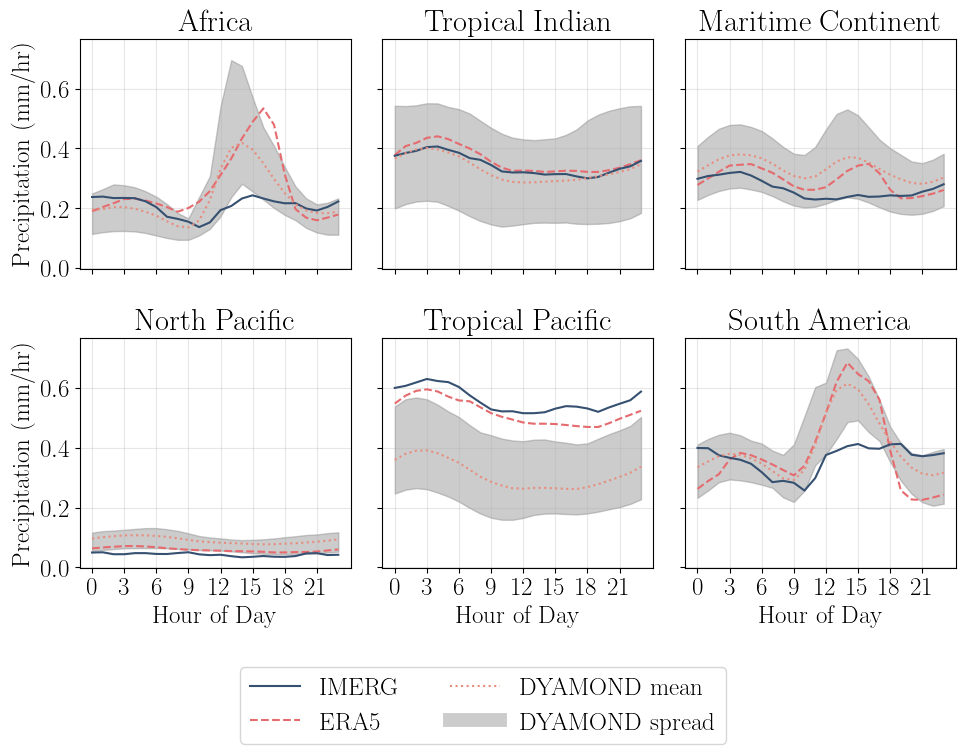

Saved figure to ../pdf/Regional_diurnal_feb2020_ERA5_IMERG_DYAMOND.pdf


In [11]:
# Function to compute regional mean for a single month (February)
# Variable names
er_var = 'pr'
imerg_var = 'pr'
model_var = 'pr'

ratio = [2,3]
figsize = (10, 7)

RELATIVE = False
fig, axes = plt.subplots(ratio[0], ratio[1], figsize=figsize, sharex=True, sharey=True)
axes = axes.flatten()

imerg_color = '#355070' 
era5_color = '#e56b6fff'
dyamond_color = '#E88C7D'

for i, (region_name, region) in enumerate(regions_plot.items()):
    ax = axes[i]
    # ERA5
    era5_cycle = regional_diurnal_feb(ERA5, er_var, region)
    if RELATIVE:
        era5_cycle = (era5_cycle / era5_cycle.mean() - 1) * 100
    ax.plot(ERA5['hour_of_day'], era5_cycle, label='ERA5', color=era5_color, linestyle='--')
    # IMERG
    imerg_cycle = regional_diurnal_feb(IMERG, imerg_var, region)
    if RELATIVE: 
        imerg_cycle = (imerg_cycle / imerg_cycle.mean() - 1) * 100
    ax.plot(IMERG['hour_of_day'], imerg_cycle, label='IMERG', color=imerg_color, linestyle='-')

    # DYAMOND MODELS
    dyamond_cycles_avg = []
    for name, ds in MODELS.items():
        ds = ds.assign_coords(lon=((ds.lon + 360) % 360)).sortby('lon')
        cycle = regional_diurnal_feb(ds, model_var, region)
        if RELATIVE:
            cycle = (cycle / cycle.mean() - 1) * 100
        dyamond_cycles_avg.append(cycle.values)

    # plot average dyamond cycle
    cycle_avg = np.mean(dyamond_cycles_avg, axis=0)
    ax.plot(ds['hour_of_day'], cycle_avg, label='DYAMOND mean', color=dyamond_color, linestyle=':')

    # DYAMOND spread
    dyamond_cycles = []
    for name, ds in MODELS.items():
        try:
            ds = ds.assign_coords(lon=((ds.lon + 360) % 360)).sortby('lon')
            cycle = regional_diurnal_feb(ds, model_var, region)
            if RELATIVE:
                cycle = (cycle / cycle.mean() - 1) * 100
            dyamond_cycles.append(cycle.values)
        except Exception as e:
            print(f"Skipping {name}: {e}")
    if dyamond_cycles:
        dyamond_cycles = np.stack(dyamond_cycles)
        min_cycle = np.min(dyamond_cycles, axis=0)
        max_cycle = np.max(dyamond_cycles, axis=0)
        ax.fill_between(ERA5['hour_of_day'], min_cycle, max_cycle, color='gray', alpha=0.4, label='DYAMOND spread')
    
    ax.set_title(region_name)
    ax.set_xticks([0,3,6,9,12,15,18,21])
    ax.grid(True, alpha=0.3)
    if i >= (ratio[0]-1)*ratio[1]:
        ax.set_xlabel('Hour of Day')
    if i % ratio[1] == 0:
        ax.set_ylabel('Precipitation (mm/hr)' if not RELATIVE else 'Relative Deviation (\%)')

import matplotlib.lines as mlines
dataset_handles = [
    mlines.Line2D([], [], color=imerg_color,  linestyle='-', label='IMERG'),
    mlines.Line2D([], [], color=era5_color, linestyle='--',label='ERA5'),
    mlines.Line2D([], [], color=dyamond_color, linestyle=':',label='DYAMOND mean'),
    mlines.Line2D([], [], color='gray', alpha=0.4, linewidth=10, label='DYAMOND spread')
]

fig.legend(dataset_handles, [h.get_label() for h in dataset_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2, frameon=True)

#plt.suptitle('February 2020 Diurnal Cycles: ERA5, IMERG, DYAMOND Spread', fontsize=25)
plt.tight_layout(rect=[0, 0, 1, 0.96])
name = '../pdf/Regional_diurnal_feb2020_ERA5_IMERG_DYAMOND' + ('_relative' if RELATIVE else '') + '.pdf' 
plt.savefig(name, bbox_inches='tight')
plt.show()
print(f'Saved figure to {name}')